<a href="https://colab.research.google.com/github/ZavalaCatalina/InteligenciaComputacional/blob/main/Redes_Convolucionales_con_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Redes Convolucionales con PyTorch
En esta actividad  consiste en crear, entrenar y evaluar una red neuronal convolucional utilizando PyTorch y el conjunto de datos CIFAR-10. Se tomó como referencia el notebook base proporcionado en clase para comprender la estructura general del flujo de trabajo.

##Importacion de librerias
Importamos PyTorch, torchvision y librerías auxiliares para visualización.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
from tqdm import tqdm

##Carga y preprocesamiento de datos

Convertimos imágenes de PIL a tensores usando transforms.ToTensor() y normalizamos.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),  # convierte PIL → Tensor
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

classes = train_dataset.classes
print(classes)

100%|██████████| 170M/170M [00:03<00:00, 42.9MB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


##Visualización de datos
Mostramos algunas imágenes para verificar que todo esté correcto.

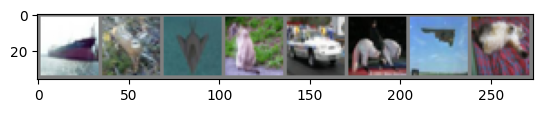

['ship', 'deer', 'airplane', 'cat', 'automobile', 'horse', 'airplane', 'cat']


In [3]:
import numpy as np

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:8]))
print([classes[l] for l in labels[:8]])

##Definición de modelos (3 arquitecturas)
Creamos 3 CNN distintas (simple, intermedia, más profunda).

###Modelo 1, Simple

In [4]:
class CNN1(nn.Module):
    def __init__(self):
        super(CNN1, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Linear(16*16*16, 10)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

###Modelo 2 Intermedio

In [5]:
class CNN2(nn.Module):
    def __init__(self):
        super(CNN2, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Linear(64*8*8, 10)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

###Modelo 3, mas profundo

In [6]:
class CNN3(nn.Module):
    def __init__(self):
        super(CNN3, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Linear(64*8*8, 10)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

##Funcion de entrenamiento

In [7]:
def train_model(model, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_losses.append(running_loss / len(train_loader))

        # evaluación
        model.eval()
        test_loss = 0.0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()

        test_losses.append(test_loss / len(test_loader))

        print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]}, Test Loss: {test_losses[-1]}")

    return train_losses, test_losses

##Entrenamiento de modelos

In [8]:
model1 = CNN1()
model2 = CNN2()
model3 = CNN3()

losses1 = train_model(model1)
losses2 = train_model(model2)
losses3 = train_model(model3)

100%|██████████| 782/782 [00:13<00:00, 57.17it/s]


Epoch 1, Train Loss: 1.4910281012430215, Test Loss: 1.2812271991353126


100%|██████████| 782/782 [00:12<00:00, 60.43it/s]


Epoch 2, Train Loss: 1.212603842434676, Test Loss: 1.1870371224773917


100%|██████████| 782/782 [00:13<00:00, 58.09it/s]


...

Epoch 8, Train Loss: 0.4900107994446974, Test Loss: 0.7704121331880047


100%|██████████| 782/782 [00:17<00:00, 44.42it/s]


Epoch 9, Train Loss: 0.44362226955573575, Test Loss: 0.7719370415256281


100%|██████████| 782/782 [00:17<00:00, 43.61it/s]


Epoch 10, Train Loss: 0.405279123626859, Test Loss: 0.8154493304574566


In [9]:
print(type(losses1))
print(len(losses1))

<class 'tuple'>
2


In [10]:
print("Train losses:", losses1[0])
print("Test losses:", losses1[1])

Train losses: [1.4910281012430215, 1.212603842434676, 1.1124309296803097, 1.0417300664707827, 0.9965064647557486, 0.9588019715245727, 0.9289551543457734, 0.9052068190958799, 0.8876376560581919, 0.871674306404865]
Test losses: [1.2812271991353126, 1.1870371224773917, 1.1880757728959346, 1.1076475518524267, 1.0706992434088591, 1.0608718478755585, 1.0731276163629666, 1.0737843186991989, 1.0718070690039616, 1.07434262363774]


##curvas de aprendizaje
Comparamos train vs test.

In [11]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [12]:
def plot_losses(train_losses, test_losses, title):
    plt.figure()

    plt.plot(train_losses, label='Train', color='hotpink', linewidth=2)
    plt.plot(test_losses, label='Test', color='green', linewidth=2)

    plt.title(title, fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

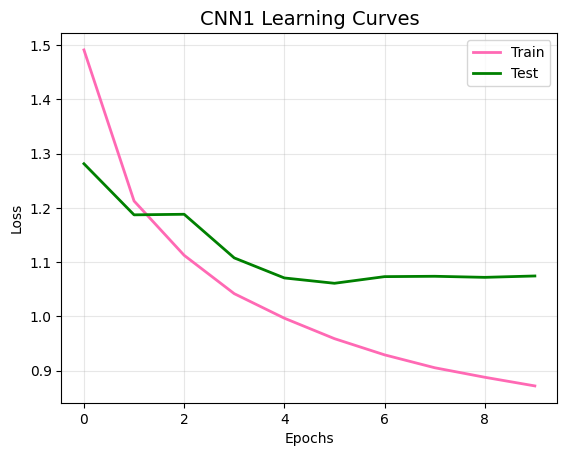

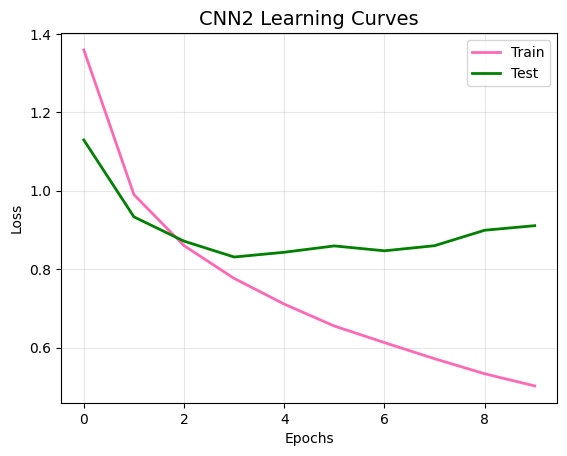

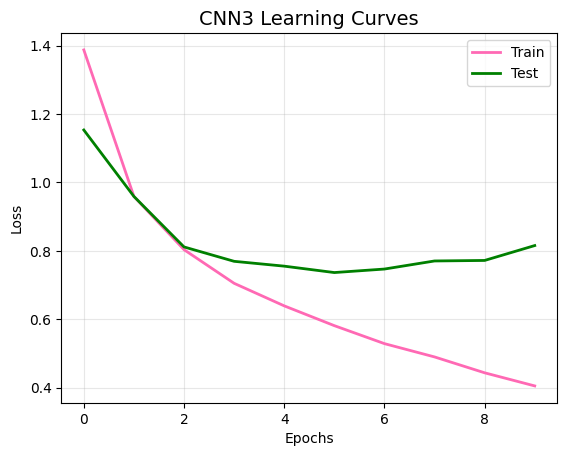

In [13]:
plot_losses(losses1[0], losses1[1], "CNN1 Learning Curves")
plot_losses(losses2[0], losses2[1], "CNN2 Learning Curves")
plot_losses(losses3[0], losses3[1], "CNN3 Learning Curves")

##Evaluación (Accuracy)

In [14]:
def evaluate(model):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

print("CNN1:", evaluate(model1))
print("CNN2:", evaluate(model2))
print("CNN3:", evaluate(model3))

CNN1: 63.17
CNN2: 71.36
CNN3: 75.09


##Reflexion

En esta actividad aprendí cómo implementar redes convolucionales desde cero en PyTorch, entendiendo el flujo completo desde la carga de datos hasta la evaluación. Noté que arquitecturas más profundas tienden a capturar mejor patrones complejos, aunque también requieren más tiempo de entrenamiento. Además, comprendí la importancia del preprocesamiento y del uso de funciones de pérdida adecuadas para clasificación multiclase.

###Nota
Para el desarrollo de esta actividad, se utilizó apoyo de herramientas de inteligencia artificial como asistencia en autocompletado y resolución de dudas específicas.